# 3. Confidence calibration: Comparing Jev vs three frontier LLMs

Jev is trained using Reinforcement Learning for Calibrated Decisions (RLCD). This means that the probability of its answers being correct should be approximately equal to its stated confidence value: i.e. `P(correct | p) ≈ p`. When it says p=0.9, it should be right about nine times in ten. This matters when a pipeline acts on the confident answers and passes the rest to a person (section 6). Notebook 02 compares accuracy, cost and latency. This notebook asks whether the confidence that comes with each answer is reliable. Jev and three frontier LLMs (Claude Haiku 4.5, an OpenAI small model and a Gemini Flash model) are compared on Banking77 (77 intents), AG News (4 topics) and IMDb (2 sentiments), zero-shot. Each dataset has its own figures.

This notebook makes no API calls. It reads the zero-shot results that `02_jev_vs_llms_benchmark.ipynb` saved in `results/`, so every number here traces to the same samples and the same responses as the accuracy tables in that notebook. Run notebook 02 first, and run this notebook again if its results change.

**What "confidence" means for each model.** The quantities differ between models, and the comparison
is only as fair as that allows.

- **Jev** returns a `confidence` with its `choice` answer, alongside a probability for every label. This is the number used for Jev, because it is the one a pipeline would gate on. The probability of the chosen label is analysed too, as a check.
- **The three LLMs** each return a `confidence` from 0 to 1 in their structured answer: the model's own estimate that its label is right. It is written out as text, not read from token probabilities. This is called 'verbalised confidence'.

Both are confidences in the chosen label only (top-label confidence). The measures are:

- **Reliability diagram:** rows are grouped by stated confidence. For each group, the diagram plots  the accuracy against the mean confidence. A perfectly calibrated model lies on the diagonal.
- **ECE** (expected calibration error): the gap between accuracy and mean confidence in each group, averaged with each group weighted by its share of the rows. Lower is better.
- **Brier score:** the mean squared difference between the confidence and the outcome (1 if the label was right, 0 if not). Lower is better. It uses every row and does not depend on how the groups are drawn.
- **Confidence-gated accuracy:** accuracy on only the rows whose confidence is at or above a threshold, and the share of rows that remain.

**Result in short** (1,000 rows per dataset, one run each). Every model is overconfident in its top
bucket on Banking77 and AG News, and ECE ranges from 0.03 to 0.14 on those two datasets. On IMDb all
four are close to calibrated (ECE 0.01 to 0.03). No model has the lowest ECE on every dataset: Haiku
is lowest on Banking77, Gemini on AG News and OpenAI on IMDb. Jev's ECE is third of four on all
three. Its Brier score is the lowest on Banking77, second on AG News and third on IMDb, where the
scores are all within 0.006. Gemini is the most accurate on Banking77 and AG News, and its Brier
score is the lowest on AG News and IMDb and within 0.002 of Jev's on Banking77. A higher confidence
threshold raises accuracy for every model, but by different amounts, and it keeps very different
shares of the rows, so the same threshold means different things for different models. At list price
Jev is the cheapest per row on every dataset. Details and caveats are in the sections below.

Sections:

1. Setup and choices made before looking at the results
2. Loading the notebook 02 results and checking them
3. The confidence values
4. Reliability diagrams, one per dataset
5. ECE, Brier score and accuracy
6. Confidence-gated accuracy, one figure per dataset
7. The most confident wrong answers
8. Cost and latency
9. Files and caveats

## 1. Setup and choices made before looking at the results

- **One sample per dataset, no resampling.** This notebook uses the stratified sample of test rows
  that notebook 02 drew for each dataset, and the responses already saved for it. No fresh sample is
  drawn and no API call is made. Calibration is therefore measured on exactly the answers behind
  the accuracy tables, at no extra cost.
- **Zero-shot only.** Every model is assessed in the same condition, with no labelled examples in
  the prompt. The few-shot results in notebook 02 also carry a confidence for every row and could be
  analysed in the same way. They are not analysed here.
- **Rows.** For each dataset, every measure uses the rows that all four models answered, so the
  models are compared on the same rows and the differences can be paired. A failed call has no
  confidence to assess. Failures are counted and listed by kind in section 2, and are not treated as
  wrong or right here. A model that failed on some rows therefore removes those rows for the others
  too.
- **Buckets.** The buckets are [0.0, 0.5), [0.5, 0.6), and so on up to [0.9, 1.0]. Steps of 0.1
  are a common choice for reliability diagrams. A model on a many-class task can be unsure enough to report less than 0.5, and the first bucket keeps those
  rows in. If many rows had fallen in it, it would have been split further (for example at 0.3).
  Section 3 shows that few do. The threshold sweep in section 6 starts at 0 for the same reason. AG News has four
  classes and IMDb has two, so the probability of a chosen label is at least 0.25 and 0.5. A
  confidence stated by a model can still be lower than that.
- **Intervals.** ECE, Brier score and accuracy each have a 95% bootstrap interval from resampling
  the rows. The same resampled rows are used for every model, so the differences between models are
  paired. Accuracy inside a single bucket, and in the gated curves, has a Wilson interval.
- **Reference model.** The question here is how Jev compares with each LLM, so differences are given
  for each LLM minus Jev. A negative ECE or Brier difference means the LLM scores better (lower) than
  Jev.
- **One run.** Every set of responses comes from a single run, so run-to-run variation is not
  measured.

In [1]:
import json

import numpy as np
import pandas as pd

from jev_compare import bench, data, plots
from jev_compare import calibration as cal

pd.set_option("display.width", 250)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 110)

# ---- settings -----------------------------------------------------------------------------
KEYS = ["jev", "haiku", "openai", "gemini"]  # models, as keys in configs/models.json
DATASETS = data.DATASETS
SHOT = "zeroshot"
EXPECTED_N = 1000  # rows in each sample (N_TEST in notebook 02)
BIN_EDGES = cal.BIN_EDGES  # (0.0, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0)
GATE_THRESHOLDS = np.round(np.arange(0.0, 0.951, 0.05), 2)
N_BOOT = cal.N_BOOT
SEED = cal.BOOT_SEED
MIN_ROWS = 10  # buckets with fewer rows are drawn as hollow points and left out of the line
# --------------------------------------------------------------------------------------------

RESULTS = bench.RESULTS
CONFIG = json.loads((data.ROOT / "configs" / "models.json").read_text(encoding="utf-8"))
MODELS = CONFIG["models"]
DATASET_NAMES = plots.DATASET_NAMES
NAMES = {**plots.NAMES, "jev_prob": "Jev (probability of chosen label)"}
VARIANTS = [*KEYS, "jev_prob"]  # the models plus Jev's second confidence, for the summary tables
print("models:", ", ".join(f"{k} ({MODELS[k]['model_id']})" for k in KEYS))

models: jev (typesafe-ai/jev), haiku (claude-haiku-4-5-20251001), openai (gpt-5.4-mini), gemini (gemini-3.8-flash)


## 2. Loading the notebook 02 results and checking them

Each results file starts with a header (model ID, parameters, what produced the run) followed by one
record per row. Before anything is computed, the notebook checks that every file is a complete
zero-shot run on the test split, that it covers exactly the rows in `results/sample_<dataset>.csv`,
and that the true labels match that file. A check that fails stops the notebook. A sample that
differs from `EXPECTED_N` only prints a warning, because a small sample is useful for testing.

In [2]:
RAW, HEADERS, SAMPLES = {}, {}, {}
for ds in DATASETS:
    sample = pd.read_csv(RESULTS / f"sample_{ds}.csv")
    SAMPLES[ds] = sample
    true_by_row = sample.set_index("row_id").label
    if len(sample) != EXPECTED_N:
        print(f"WARNING: {ds} has {len(sample)} rows, not {EXPECTED_N}. Do not use these results.")
    for k in KEYS:
        path = RESULTS / f"results_{k}_{SHOT}_{ds}.jsonl"
        if not path.exists():
            raise FileNotFoundError(f"Run notebook 02 first. Missing from results/: {path.name}")
        df, h = bench.load_results(path), bench.read_header(path)
        where = f"{k} {ds}"
        assert (h["dataset"], h["split"], h["shot"]) == (ds, "test", SHOT), (
            f"{where}: wrong condition"
        )
        assert not h["few_shot_examples"], f"{where}: the file has few-shot examples"
        assert len(df) == h["n_rows"], (
            f"{where}: {len(df)} rows in the file, {h['n_rows']} expected. "
            "The run stopped early or is still being written."
        )
        assert set(df.row_id) == set(sample.row_id), f"{where}: rows differ from the sample file"
        assert (true_by_row.loc[df.row_id].to_numpy() == df.true_label.to_numpy()).all(), (
            f"{where}: true labels differ from the sample file"
        )
        RAW[(ds, k)], HEADERS[(ds, k)] = df, h

pd.DataFrame(
    [
        {
            "dataset": ds,
            "model": k,
            "model ID requested": HEADERS[(ds, k)]["model_id_requested"],
            "model ID returned": "; ".join(RAW[(ds, k)].model_returned.dropna().unique()),
            "run at (UTC)": HEADERS[(ds, k)]["run_at"],
            "rows": len(RAW[(ds, k)]),
            "code hash": HEADERS[(ds, k)]["provenance"]["code_sha256"][:10],
        }
        for ds in DATASETS
        for k in KEYS
    ]
).set_index(["dataset", "model"])

model ID requested          model ID returned               run at (UTC)  rows   code hash
dataset   model                                                                                                    
banking77 jev               typesafe-ai/jev            typesafe-ai/jev  2026-09-20T23:52:55+00:00  1000  069690afd4
          haiku   claude-haiku-4-5-20251001  claude-haiku-4-5-20251001  2026-09-21T01:11:16+00:00  1000  069690afd4
          openai               gpt-5.4-mini    gpt-5.4-mini-2026-03-17  2026-09-21T01:19:37+00:00  1000  069690afd4
          gemini           gemini-3.8-flash           gemini-3.8-flash  2026-09-21T01:47:52+00:00  1000  069690afd4
ag_news   jev               typesafe-ai/jev            typesafe-ai/jev  2026-09-21T02:00:11+00:00  1000  069690afd4
          haiku   claude-haiku-4-5-20251001  claude-haiku-4-5-20251001  2026-09-21T03:14:18+00:00  1000  069690afd4
          openai               gpt-5.4-mini    gpt-5.4-mini-2026-03-17  2026-09-21T03:21:07+00:00  1000  069690afd4
          gemini           gemini-3.8-flash           gemini-3.8-flash  2026-09-21T03:29:16+00:00  1000  069690afd4
imdb      jev               typesafe-ai/jev            typesafe-ai/jev  2026-09-21T03:40:54+00:00  1000  069690afd4
          haiku   claude-haiku-4-5-20251001  claude-haiku-4-5-20251001  2026-09-21T05:32:12+00:00  1000  069690afd4
          openai               gpt-5.4-mini    gpt-5.4-mini-2026-03-17  2026-09-21T05:42:20+00:00  1000  069690afd4
          gemini           gemini-3.8-flash           gemini-3.8-flash  2026-09-21T05:56:28+00:00  1000  069690afd4

**Failed calls.** A call that still failed after retries has no answer and no confidence. The table
shows how many there were for each model and why. Model behaviour (unusable output, refusal,
incomplete output) and infrastructure (rate limits, network) are told apart, as in notebook 02.

In [3]:
failed = pd.concat([RAW[key].assign(dataset=key[0], model=key[1]) for key in RAW])
failed = failed[failed.status != "ok"]
if len(failed):
    print("Failed rows by dataset, model and kind:")
    display(failed.groupby(["dataset", "model", "error_kind"]).size().rename("rows"))
else:
    print("No failed rows for any model.")

EVAL, CORRECT, CONF = {}, {}, {}
counts = []
for ds in DATASETS:
    answered = [set(RAW[(ds, k)].query("status == 'ok'").row_id) for k in KEYS]
    ids = sorted(set.intersection(*answered))
    counts.append(
        {"dataset": ds, "rows in sample": len(SAMPLES[ds]), "rows all models answered": len(ids)}
    )
    for k in KEYS:
        e = RAW[(ds, k)].set_index("row_id").loc[ids]
        EVAL[(ds, k)] = e
        CORRECT[(ds, k)] = (e.pred == e.true_label).to_numpy()
        CONF[(ds, k)] = e.confidence.astype(float).to_numpy()
        assert not np.isnan(CONF[(ds, k)]).any(), f"{k} {ds}: an answered row has no confidence"
        assert ((CONF[(ds, k)] >= 0) & (CONF[(ds, k)] <= 1)).all(), (
            f"{k} {ds}: confidence outside 0 to 1"
        )
    # Second confidence for Jev: the probability of the label it chose. It is a separate quantity from
    # the `confidence` field, so the two are compared rather than assumed equal.
    jev = EVAL[(ds, "jev")]
    CONF[(ds, "jev_prob")] = np.array(
        [p[label] for p, label in zip(jev.probs, jev.pred, strict=True)]
    )
    CORRECT[(ds, "jev_prob")] = CORRECT[(ds, "jev")]
    agree = np.mean(
        [max(p, key=p.get) == label for p, label in zip(jev.probs, jev.pred, strict=True)]
    )
    counts[-1]["Jev's label is its most probable"] = f"{agree:.1%}"
pd.DataFrame(counts).set_index("dataset")

Failed rows by dataset, model and kind:


dataset  model   error_kind
imdb     gemini  incomplete    6
Name: rows, dtype: int64

,rows in sample,rows all models answered,Jev's label is its most probable
dataset,,,
banking77,1000,1000,100.0%
ag_news,1000,1000,100.0%
imdb,1000,994,100.0%


## 3. The confidence values

Before the buckets are read, this shows what values each model reports. It shows how many rows fall
below 0.5, so how much the first bucket matters, and how many distinct values each model uses. A
model that reports only a few values cannot fill the buckets evenly, and that limits what a
reliability diagram can show. `most common value` gives the value and the number of rows that have
it.

In [4]:
def describe(c):
    values, counts = np.unique(c, return_counts=True)
    top = counts.argmax()
    return {
        "rows": len(c),
        "below 0.5": int((c < 0.5).sum()),
        "0.5 to below 0.9": int(((c >= 0.5) & (c < 0.9)).sum()),
        "0.9 to below 1": int(((c >= 0.9) & (c < 1)).sum()),
        "exactly 1": int((c == 1).sum()),
        "distinct values": len(values),
        "minimum": round(float(c.min()), 3),
        "median": round(float(np.median(c)), 3),
        "most common value": f"{values[top]:g} ({counts[top]})",
    }


pd.DataFrame(
    {(DATASET_NAMES[ds], NAMES[k]): describe(CONF[(ds, k)]) for ds in DATASETS for k in VARIANTS}
).T

rows below 0.5 0.5 to below 0.9 0.9 to below 1 exactly 1 distinct values minimum median most common value
Banking77 Jev                                1000        37              202            254       507              70    0.27    1.0           1 (507)
          Claude Haiku 4.5                   1000        33              374            593         0              13    0.35   0.95        0.95 (485)
          OpenAI small                       1000        13              104            883         0              45    0.16   0.98        0.98 (386)
          Gemini Flash                       1000         2              141            826        31              16    0.45   0.98        0.95 (281)
          Jev (probability of chosen label)  1000        28              201            240       531              68    0.29    1.0           1 (531)
AG News   Jev                                1000        29               92            156       723              61    0.33    1.0           1 (723)
          Claude Haiku 4.5                   1000        16              221            763         0              11    0.15   0.95        0.95 (432)
          OpenAI small                       1000         0               88            912         0              34    0.52   0.98        0.99 (463)
          Gemini Flash                       1000         0              246            746         8              14    0.55   0.99        0.99 (493)
          Jev (probability of chosen label)  1000         0              108            150       742              50     0.5    1.0           1 (742)
IMDb      Jev                                 994        21               35             97       841              51    0.02    1.0           1 (841)
          Claude Haiku 4.5                    994         0              191            803         0               8    0.72   0.95        0.98 (275)
          OpenAI small                        994         0               74            920         0              31    0.61   0.99        0.99 (532)
          Gemini Flash                        994         0              105            765       124              13    0.55   0.99        0.99 (379)
          Jev (probability of chosen label)   994         0               40             86       868              35    0.51    1.0           1 (868)

**What the table shows.** The models report confidence in different ways. Jev uses the most distinct
values (51 to 70) and gives exactly 1 on about half of the Banking77 rows and on most of the AG News
and IMDb rows (72% and 85%). Haiku and OpenAI never give 1, and Gemini gives it on 3%, 1% and 12% of
rows. Haiku uses only 8 to 13 distinct values, with 0.95 the commonest on Banking77 and AG News. Few
rows fall below 0.5 (at most 37 for any model on any dataset), so the first bucket is enough.

On IMDb, Jev's `confidence` is below 0.5 on 21 rows and goes as low as 0.02, although with two
labels the probability of its chosen label cannot be below 0.5. So Jev's `confidence` is not the
probability of the chosen label, and the two are analysed separately (the last row of each group).

## 4. Reliability diagrams, one per dataset

Rows are grouped into buckets by stated confidence. Each point is one bucket, placed at the mean
confidence of its rows, and its height is the accuracy of those rows. The marker area shows how many
rows are in the bucket, and the bars underneath give the same counts. A bucket with few rows is
noisy. With four models the whiskers would overlap, so the figures leave them out. The 95% Wilson
interval for each bucket's accuracy is in the table above each figure. Buckets with no rows have no
point. A bucket with fewer than `MIN_ROWS` (10) rows is drawn as a hollow point and left out of
the line, because a handful of rows says little. Each figure is saved to
`results/reliability_<dataset>.png`.

`gap` is accuracy minus mean confidence. A negative gap means the model was overconfident in that
bucket (it was right less often than it said), and a positive gap means it was underconfident.

In [5]:
TABLES = {
    (ds, k): cal.reliability_table(CONF[(ds, k)], CORRECT[(ds, k)], BIN_EDGES)
    for ds in DATASETS
    for k in KEYS
}


def show_reliability(ds):
    cols = {}
    for k in KEYS:
        t = TABLES[(ds, k)].set_index("bucket")
        acc = t.apply(
            lambda r: (
                "" if r.n == 0 else f"{r.accuracy:.2f} [{r.accuracy_lo:.2f}, {r.accuracy_hi:.2f}]"
            ),
            axis=1,
        )
        cols[(NAMES[k], "rows")] = t.n
        cols[(NAMES[k], "mean confidence")] = t.mean_confidence.round(3)
        cols[(NAMES[k], "accuracy [95% interval]")] = acc
        cols[(NAMES[k], "gap")] = t.gap.round(3)
    return pd.DataFrame(cols)


def reliability_figure(ds):
    n = len(EVAL[(ds, KEYS[0])])
    subtitle = f"Zero-shot, {n} rows, one run. Marker area: rows. Hollow: under {MIN_ROWS} rows, not joined."
    return plots.plot_reliability(
        {k: TABLES[(ds, k)] for k in KEYS},
        BIN_EDGES,
        subtitle,
        path=RESULTS / f"reliability_{ds}.png",
        title=f"Calibration reliability on {DATASET_NAMES[ds]}",
        min_rows=MIN_ROWS,
    )

### Banking77 (77 intents)

Jev                                                Claude Haiku 4.5                                                OpenAI small                                                Gemini Flash                                               
           rows mean confidence accuracy [95% interval]    gap             rows mean confidence accuracy [95% interval]    gap         rows mean confidence accuracy [95% interval]    gap         rows mean confidence accuracy [95% interval]    gap
bucket                                                                                                                                                                                                                                                
[0.0, 0.5)   37           0.427       0.19 [0.09, 0.34] -0.238               33           0.426       0.15 [0.07, 0.31] -0.274           13           0.311       0.38 [0.18, 0.64]  0.074            2            0.45       1.00 [0.34, 1.00]  0.550
[0.5, 0.6)   35           0.538       0.34 [0.21, 0.51] -0.195                0             NaN                            NaN            7           0.557       0.14 [0.03, 0.51] -0.414            3            0.55       0.67 [0.21, 0.94]  0.117
[0.6, 0.7)   46           0.642       0.37 [0.25, 0.51] -0.273               17           0.629       0.53 [0.31, 0.74] -0.100           10           0.647       0.40 [0.17, 0.69] -0.247            6            0.65       0.50 [0.19, 0.81] -0.150
[0.7, 0.8)   48           0.740       0.46 [0.33, 0.60] -0.282              107           0.746       0.59 [0.49, 0.68] -0.157           21           0.754       0.43 [0.24, 0.63] -0.326            3            0.75       0.33 [0.06, 0.79] -0.417
[0.8, 0.9)   73           0.853       0.58 [0.46, 0.68] -0.278              250           0.850       0.69 [0.63, 0.74] -0.162           66           0.862       0.44 [0.33, 0.56] -0.422          129            0.85       0.50 [0.41, 0.58] -0.353
[0.9, 1.0]  761           0.989       0.92 [0.90, 0.94] -0.070              593           0.950       0.91 [0.88, 0.93] -0.044          883           0.974       0.86 [0.84, 0.88] -0.111          857            0.97       0.90 [0.88, 0.92] -0.070

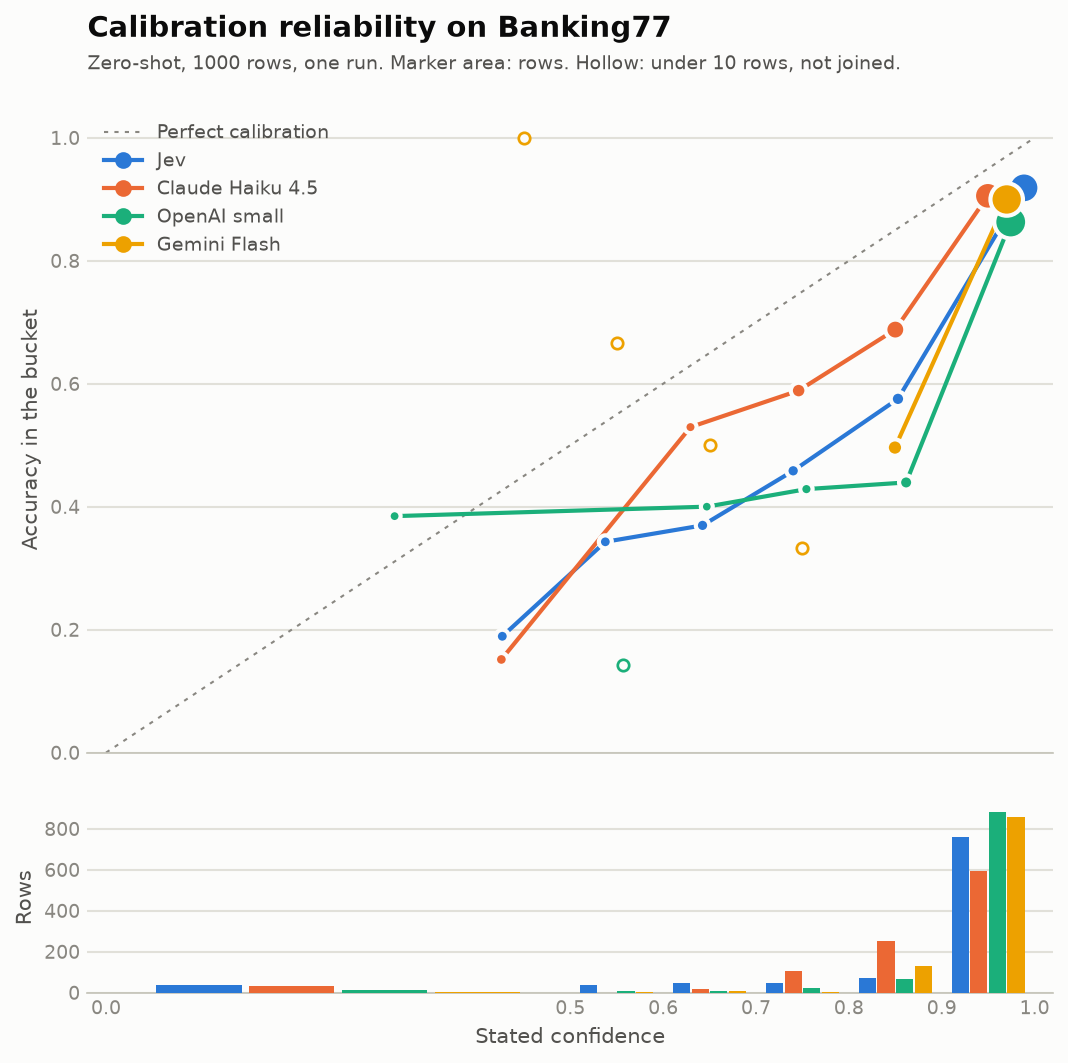

In [6]:
ds = "banking77"
display(show_reliability(ds))
fig = reliability_figure(ds)

**What the diagram shows.** All four models are overconfident in the top bucket ([0.9, 1.0]), which
holds most rows. Mean confidence against accuracy is 0.989 against 0.92 for Jev (761 rows), 0.950
against 0.91 for Haiku (593), 0.974 against 0.86 for OpenAI (883) and 0.97 against 0.90 for Gemini
(857). Below 0.9 the buckets hold fewer rows, and every model that has a meaningful number of rows
there is well below the diagonal. The 0.8 to 0.9 bucket is the worst: the answers were right 44% of
the time for OpenAI (66 rows), 50% for Gemini (129), 58% for Jev (73) and 69% for Haiku (250).
Haiku is closest to the diagonal. Gemini and OpenAI have few rows in most buckets below 0.8, so
their lines there rest on hollow points, which say little.

### AG News (4 topics)

Jev                                                Claude Haiku 4.5                                                OpenAI small                                                Gemini Flash                                               
           rows mean confidence accuracy [95% interval]    gap             rows mean confidence accuracy [95% interval]    gap         rows mean confidence accuracy [95% interval]    gap         rows mean confidence accuracy [95% interval]    gap
bucket                                                                                                                                                                                                                                                
[0.0, 0.5)   29           0.418       0.59 [0.41, 0.74]  0.168               16           0.419       0.38 [0.18, 0.61] -0.044            0             NaN                            NaN            0             NaN                            NaN
[0.5, 0.6)   25           0.534       0.64 [0.45, 0.80]  0.106                0             NaN                            NaN            4           0.552       0.75 [0.30, 0.95]  0.198           20           0.550       0.65 [0.43, 0.82]  0.100
[0.6, 0.7)   16           0.630       0.44 [0.23, 0.67] -0.193               13           0.650       0.69 [0.42, 0.87]  0.042            7           0.657       0.43 [0.16, 0.75] -0.229           10           0.650       0.60 [0.31, 0.83] -0.050
[0.7, 0.8)   26           0.753       0.65 [0.46, 0.81] -0.099               73           0.748       0.66 [0.54, 0.76] -0.091           24           0.763       0.25 [0.12, 0.45] -0.513           42           0.735       0.64 [0.49, 0.77] -0.092
[0.8, 0.9)   25           0.856       0.72 [0.52, 0.86] -0.136              135           0.850       0.75 [0.67, 0.81] -0.102           53           0.859       0.57 [0.43, 0.69] -0.293          174           0.845       0.79 [0.72, 0.84] -0.058
[0.9, 1.0]  879           0.994       0.92 [0.90, 0.93] -0.077              763           0.948       0.91 [0.89, 0.93] -0.038          912           0.979       0.90 [0.87, 0.91] -0.083          754           0.980       0.96 [0.94, 0.97] -0.022

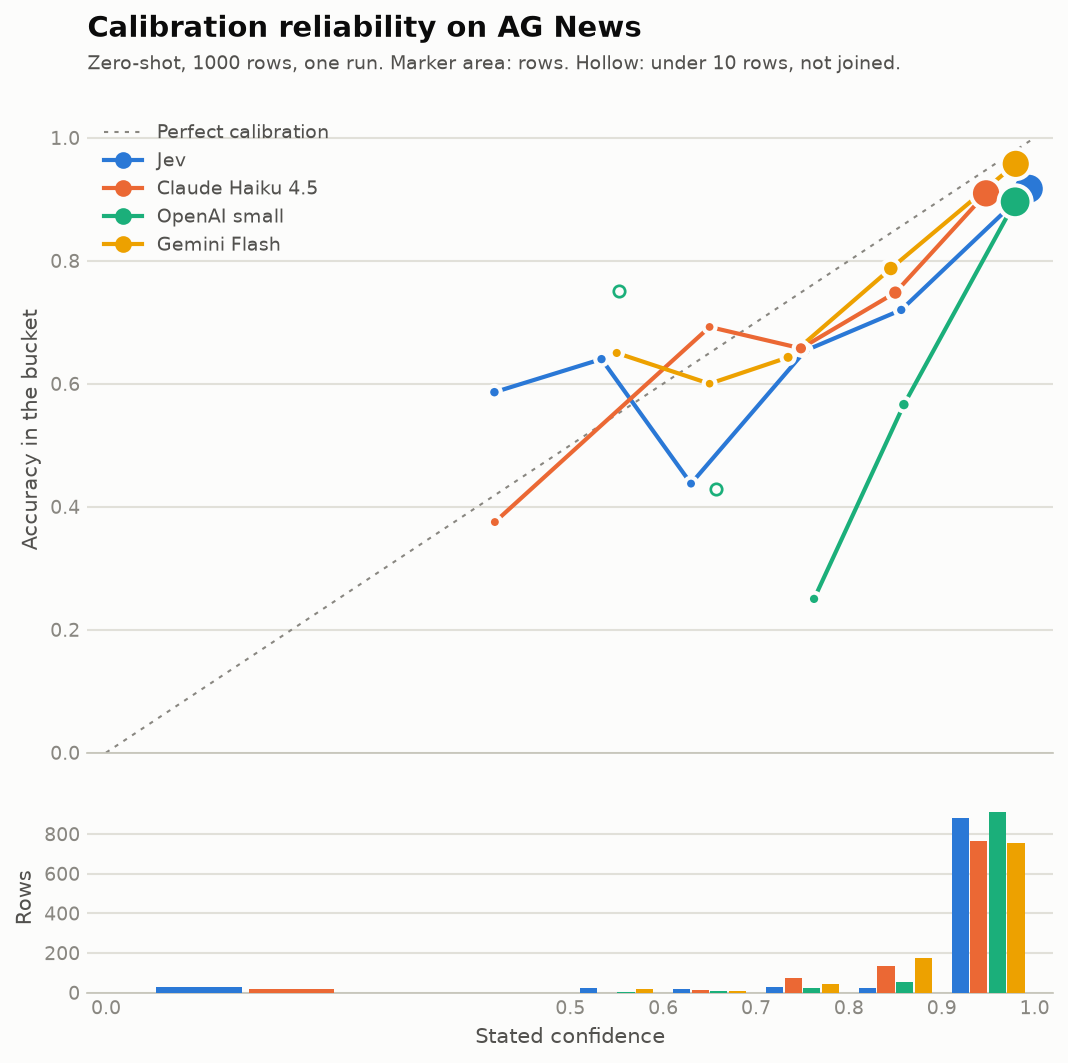

In [7]:
ds = "ag_news"
display(show_reliability(ds))
fig = reliability_figure(ds)

**What the diagram shows.** The top bucket holds 75% to 91% of the rows. Mean confidence against
accuracy there is 0.994 against 0.92 for Jev (879 rows), 0.948 against 0.91 for Haiku (763), 0.979
against 0.90 for OpenAI (912) and 0.98 against 0.96 for Gemini (754). Gemini is closest to the
diagonal, and Jev and OpenAI are furthest from it. The lower buckets are noisier. The largest are
Haiku's 0.8 to 0.9 bucket (135 rows, accuracy 0.75 against 0.85 stated) and Gemini's (174 rows, 0.79
against 0.845). OpenAI's buckets from 0.7 to 0.9 (24 and 53 rows) are far below the diagonal, at
accuracies of 0.25 and 0.57. Jev's answers stated below 0.6 were right more often than stated (0.59
and 0.64, on 29 and 25 rows), but the intervals include the stated confidence.

### IMDb (2 sentiments)

Jev                                                Claude Haiku 4.5                                                OpenAI small                                                Gemini Flash                                               
           rows mean confidence accuracy [95% interval]    gap             rows mean confidence accuracy [95% interval]    gap         rows mean confidence accuracy [95% interval]    gap         rows mean confidence accuracy [95% interval]    gap
bucket                                                                                                                                                                                                                                                
[0.0, 0.5)   21           0.256       0.43 [0.24, 0.63]  0.173                0             NaN                            NaN            0             NaN                            NaN            0             NaN                            NaN
[0.5, 0.6)    3           0.550       1.00 [0.44, 1.00]  0.450                0             NaN                            NaN            0             NaN                            NaN            2           0.550       0.50 [0.09, 0.91] -0.050
[0.6, 0.7)   11           0.645       0.55 [0.28, 0.79] -0.100                0             NaN                            NaN           10           0.647       0.70 [0.40, 0.89]  0.053            9           0.650       0.67 [0.35, 0.88]  0.017
[0.7, 0.8)    6           0.762       0.50 [0.19, 0.81] -0.262              100           0.730       0.71 [0.61, 0.79] -0.020           23           0.754       0.70 [0.49, 0.84] -0.058           27           0.728       0.70 [0.52, 0.84] -0.024
[0.8, 0.9)   15           0.858       0.80 [0.55, 0.93] -0.058               91           0.845       0.90 [0.82, 0.95]  0.056           41           0.860       0.78 [0.63, 0.88] -0.080           67           0.846       0.73 [0.61, 0.82] -0.115
[0.9, 1.0]  938           0.997       0.98 [0.96, 0.98] -0.020              803           0.965       0.99 [0.98, 1.00]  0.027          920           0.983       0.98 [0.97, 0.99] -0.004          889           0.986       0.99 [0.98, 1.00]  0.005

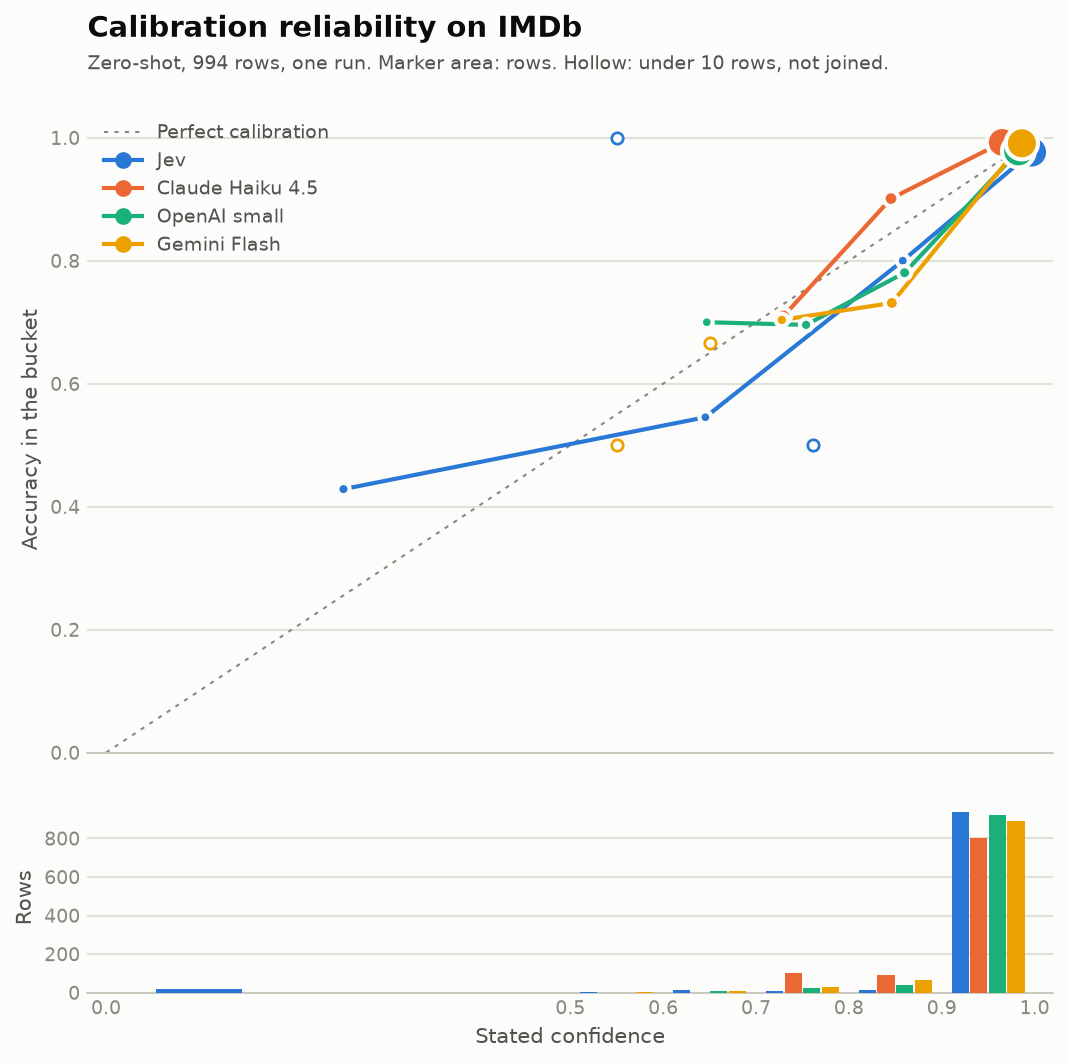

In [8]:
ds = "imdb"
display(show_reliability(ds))
fig = reliability_figure(ds)

**What the diagram shows.** All four models are close to calibrated, because 81% to 94% of rows are
in the top bucket, where accuracy is 0.98 or 0.99. Haiku is underconfident there (0.965 stated
against 0.99 achieved) and Jev slightly overconfident (0.997 against 0.98). The other buckets hold
few rows (fewer than 25 for Jev in each of them), so the lines below 0.9 rest mostly on hollow
points.

## 5. ECE, Brier score and accuracy

ECE and Brier score are the summary numbers. Each has a 95% bootstrap interval. The first three
tables give the value for every model and dataset, on the rows all four models answered. The last
table gives each LLM minus Jev, with a paired interval, and marks with `*` a difference whose
interval excludes zero (the sampled rows support a difference in one direction). For ECE and Brier
score a negative difference means the LLM is lower (better) than Jev.

Accuracy is included because a calibration score can be good simply because a model is right most
of the time and says so. The `Jev (probability of chosen label)` column uses the probability of
Jev's chosen label in place of its `confidence` field, to show whether the choice of field matters.

ECE is biased upwards in small samples and depends on where the bucket edges fall. Read the
intervals before the point values. An interval shows how far the score could move with a different
draw of rows, but not run-to-run variation. With this many comparisons, an isolated difference that
excludes zero is weak evidence.

In [9]:
frames = []
for ds in DATASETS:
    s = cal.summarise(
        {k: CONF[(ds, k)] for k in VARIANTS},
        {k: CORRECT[(ds, k)] for k in VARIANTS},
        BIN_EDGES,
        N_BOOT,
        SEED,
        reference="jev",
    )
    frames.append(s.assign(dataset=ds, n_rows=len(EVAL[(ds, "jev")])))
SUMMARY = pd.concat(frames, ignore_index=True)
SUMMARY["model"] = SUMMARY.predictor.map(lambda p: NAMES.get(p, p))
SUMMARY["bin_edges"] = json.dumps(list(BIN_EDGES))
SUMMARY["n_boot"] = N_BOOT

ORDER = [*VARIANTS]
DIFFS = [f"{k} minus jev" for k in KEYS if k != "jev"]  # 'jev_prob minus jev' stays in the CSV only


def value_table(measure):
    s = SUMMARY[(SUMMARY.measure == measure) & SUMMARY.predictor.isin(ORDER)]
    text = s.apply(lambda r: f"{r.value:.3f} [{r.lo:.3f}, {r.hi:.3f}]", axis=1)
    out = s.assign(text=text).pivot(index="dataset", columns="predictor", values="text")
    out = out.reindex(index=list(DATASETS), columns=ORDER)
    out.columns = [NAMES[c] for c in out.columns]
    out.index = [DATASET_NAMES[d] for d in out.index]
    return out


for measure, label in [("accuracy", "Accuracy"), ("ece", "ECE"), ("brier", "Brier score")]:
    print(f"{label}, with a 95% bootstrap interval:")
    display(value_table(measure))

Accuracy, with a 95% bootstrap interval:


,Jev,Claude Haiku 4.5,OpenAI small,Gemini Flash,Jev (probability of chosen label)
Banking77,"0.799 [0.774, 0.823]","0.786 [0.760, 0.810]","0.810 [0.785, 0.832]","0.843 [0.821, 0.864]","0.799 [0.774, 0.823]"
AG News,"0.881 [0.861, 0.901]","0.858 [0.835, 0.880]","0.859 [0.838, 0.882]","0.905 [0.887, 0.923]","0.881 [0.861, 0.901]"
IMDb,"0.955 [0.942, 0.967]","0.956 [0.943, 0.969]","0.961 [0.949, 0.973]","0.962 [0.950, 0.974]","0.955 [0.942, 0.967]"


ECE, with a 95% bootstrap interval:


,Jev,Claude Haiku 4.5,OpenAI small,Gemini Flash,Jev (probability of chosen label)
Banking77,"0.115 [0.094, 0.137]","0.094 [0.073, 0.119]","0.139 [0.119, 0.163]","0.109 [0.090, 0.131]","0.120 [0.098, 0.141]"
AG News,"0.084 [0.067, 0.104]","0.051 [0.033, 0.074]","0.106 [0.086, 0.127]","0.033 [0.019, 0.051]","0.084 [0.068, 0.104]"
IMDb,"0.028 [0.018, 0.040]","0.029 [0.023, 0.041]","0.009 [0.004, 0.022]","0.013 [0.007, 0.026]","0.033 [0.022, 0.045]"


Brier score, with a 95% bootstrap interval:


,Jev,Claude Haiku 4.5,OpenAI small,Gemini Flash,Jev (probability of chosen label)
Banking77,"0.129 [0.113, 0.146]","0.151 [0.134, 0.169]","0.156 [0.137, 0.177]","0.131 [0.113, 0.149]","0.131 [0.115, 0.149]"
AG News,"0.101 [0.084, 0.116]","0.114 [0.098, 0.132]","0.120 [0.102, 0.139]","0.077 [0.064, 0.090]","0.102 [0.085, 0.118]"
IMDb,"0.035 [0.025, 0.045]","0.036 [0.028, 0.044]","0.033 [0.024, 0.043]","0.030 [0.021, 0.038]","0.036 [0.026, 0.047]"


In [10]:
d = SUMMARY[SUMMARY.predictor.isin(DIFFS)].copy()
d["text"] = d.apply(
    lambda r: (
        f"{r.value:+.3f} [{r.lo:+.3f}, {r.hi:+.3f}]" + (" *" if r.interval_excludes_zero else "")
    ),
    axis=1,
)
table = d.pivot(index=["dataset", "measure"], columns="predictor", values="text")
table = table.reindex(
    index=pd.MultiIndex.from_product([DATASETS, ["accuracy", "ece", "brier"]]), columns=DIFFS
)
table.columns = [NAMES[c.split(" minus ")[0]] + " minus Jev" for c in table.columns]
table = table.rename(index=DATASET_NAMES, level=0)
print("Each LLM minus Jev, with a 95% paired bootstrap interval (* = interval excludes zero):")
table

Each LLM minus Jev, with a 95% paired bootstrap interval (* = interval excludes zero):


Claude Haiku 4.5 minus Jev     OpenAI small minus Jev     Gemini Flash minus Jev
Banking77 accuracy    -0.013 [-0.030, +0.003]    +0.011 [-0.005, +0.028]  +0.044 [+0.029, +0.060] *
          ece       -0.021 [-0.036, -0.004] *  +0.024 [+0.008, +0.041] *    -0.006 [-0.021, +0.011]
          brier     +0.021 [+0.010, +0.033] *  +0.027 [+0.014, +0.040] *    +0.002 [-0.009, +0.013]
AG News   accuracy  -0.023 [-0.036, -0.011] *  -0.022 [-0.036, -0.009] *  +0.024 [+0.012, +0.036] *
          ece       -0.033 [-0.047, -0.016] *  +0.022 [+0.006, +0.037] *  -0.051 [-0.063, -0.038] *
          brier     +0.013 [+0.005, +0.023] *  +0.019 [+0.010, +0.029] *  -0.024 [-0.030, -0.017] *
IMDb      accuracy    +0.001 [-0.006, +0.009]    +0.006 [-0.002, +0.015]    +0.007 [-0.002, +0.016]
          ece         +0.001 [-0.014, +0.019]  -0.019 [-0.026, -0.008] *  -0.015 [-0.025, -0.000] *
          brier       +0.001 [-0.005, +0.007]    -0.002 [-0.007, +0.004]  -0.005 [-0.011, -0.000] *

**What the numbers show.**

- **Accuracy.** Gemini is the most accurate on Banking77 (0.843, which is 0.044 above Jev) and on AG
  News (0.905, 0.024 above Jev). On IMDb the four are within 0.007 and no difference excludes zero.
  Jev is more accurate than Haiku and OpenAI on AG News (by 0.022 to 0.023) and level with them on
  the other two datasets.
- **ECE.** Jev's ECE is 0.115 on Banking77, 0.084 on AG News and 0.028 on IMDb, which is third of
  four on each. The lowest is Haiku on Banking77 (0.094), Gemini on AG News (0.033) and OpenAI on
  IMDb (0.009). OpenAI has the highest ECE on Banking77 (0.139) and AG News (0.106). Every
  difference from Jev excludes zero except Gemini's on Banking77 and Haiku's on IMDb.
- **Brier score.** Jev's is the lowest on Banking77 (0.129), although Gemini's difference (+0.002)
  includes zero. On AG News Gemini is lower (0.077 against 0.101) and Haiku and OpenAI are higher. On
  IMDb the four scores are within 0.006, and only Gemini's difference (-0.005) has an interval that
  excludes zero, and only just.
- **The two measures rank the models differently.** On Banking77 Haiku has the lowest ECE and a
  higher Brier score than Jev. ECE measures only the gap between confidence and accuracy within each
  bucket. Brier score also rewards confidence that separates right answers from wrong ones, which
  section 6 looks at.
- **Jev's second confidence.** Using the probability of Jev's chosen label in place of its
  `confidence` field changes ECE by no more than 0.005 on each dataset.

With nine comparisons against Jev for each measure, a single difference that only just excludes
zero is weak evidence.

## 6. Confidence-gated accuracy, one figure per dataset

A pipeline can act on the answers above a confidence threshold and pass the rest to a person. This
sweeps the threshold. The left panel of each figure shows the accuracy of the answers at or above
each threshold, and the right panel shows the share of all rows that clear it. Together they show
what accuracy a threshold gives and how many rows it leaves for automatic handling. The sweep
starts at 0, so that the first point is the accuracy of the whole sample and rows with a confidence
below 0.5 are included. Intervals (95%, Wilson) are in the tables and not on the figures.
Each figure is saved to `results/gated_accuracy_<dataset>.png`.

In [11]:
CURVES = {
    (ds, k): cal.gated_curve(CONF[(ds, k)], CORRECT[(ds, k)], GATE_THRESHOLDS)
    for ds in DATASETS
    for k in KEYS
}
PICKED = [0.0, 0.5, 0.7, 0.8, 0.9, 0.95]


def show_gated(ds):
    cols = {}
    for k in KEYS:
        c = CURVES[(ds, k)]
        c = c[c.threshold.isin(PICKED)].set_index("threshold")
        cols[(NAMES[k], "share kept")] = c.coverage.round(3)
        cols[(NAMES[k], "accuracy [95% interval]")] = c.apply(
            lambda r: (
                ""
                if r.n_kept == 0
                else f"{r.accuracy:.3f} [{r.accuracy_lo:.3f}, {r.accuracy_hi:.3f}]"
            ),
            axis=1,
        )
    return pd.DataFrame(cols)


def gated_figure(ds):
    n = len(EVAL[(ds, KEYS[0])])
    return plots.plot_gated(
        {k: CURVES[(ds, k)] for k in KEYS},
        f"{DATASET_NAMES[ds]}, zero-shot, {n} rows, one run.",
        path=RESULTS / f"gated_accuracy_{ds}.png",
        title=f"What a confidence threshold does on {DATASET_NAMES[ds]}",
    )

### Banking77

Jev                         Claude Haiku 4.5                         OpenAI small                         Gemini Flash                        
          share kept accuracy [95% interval]       share kept accuracy [95% interval]   share kept accuracy [95% interval]   share kept accuracy [95% interval]
threshold                                                                                                                                                      
0.00           1.000    0.799 [0.773, 0.823]            1.000    0.786 [0.760, 0.810]        1.000    0.810 [0.785, 0.833]        1.000    0.843 [0.819, 0.864]
0.50           0.963    0.822 [0.797, 0.845]            0.967    0.808 [0.782, 0.831]        0.987    0.816 [0.790, 0.839]        0.998    0.843 [0.819, 0.864]
0.70           0.882    0.865 [0.841, 0.886]            0.950    0.813 [0.787, 0.836]        0.970    0.825 [0.800, 0.847]        0.989    0.845 [0.821, 0.866]
0.80           0.834    0.888 [0.865, 0.908]            0.843    0.841 [0.815, 0.864]        0.949    0.834 [0.808, 0.856]        0.986    0.847 [0.823, 0.868]
0.90           0.761    0.919 [0.897, 0.936]            0.593    0.906 [0.879, 0.927]        0.883    0.863 [0.839, 0.884]        0.857    0.900 [0.878, 0.918]
0.95           0.704    0.935 [0.914, 0.951]            0.529    0.930 [0.905, 0.949]        0.803    0.884 [0.860, 0.905]        0.803    0.917 [0.895, 0.934]

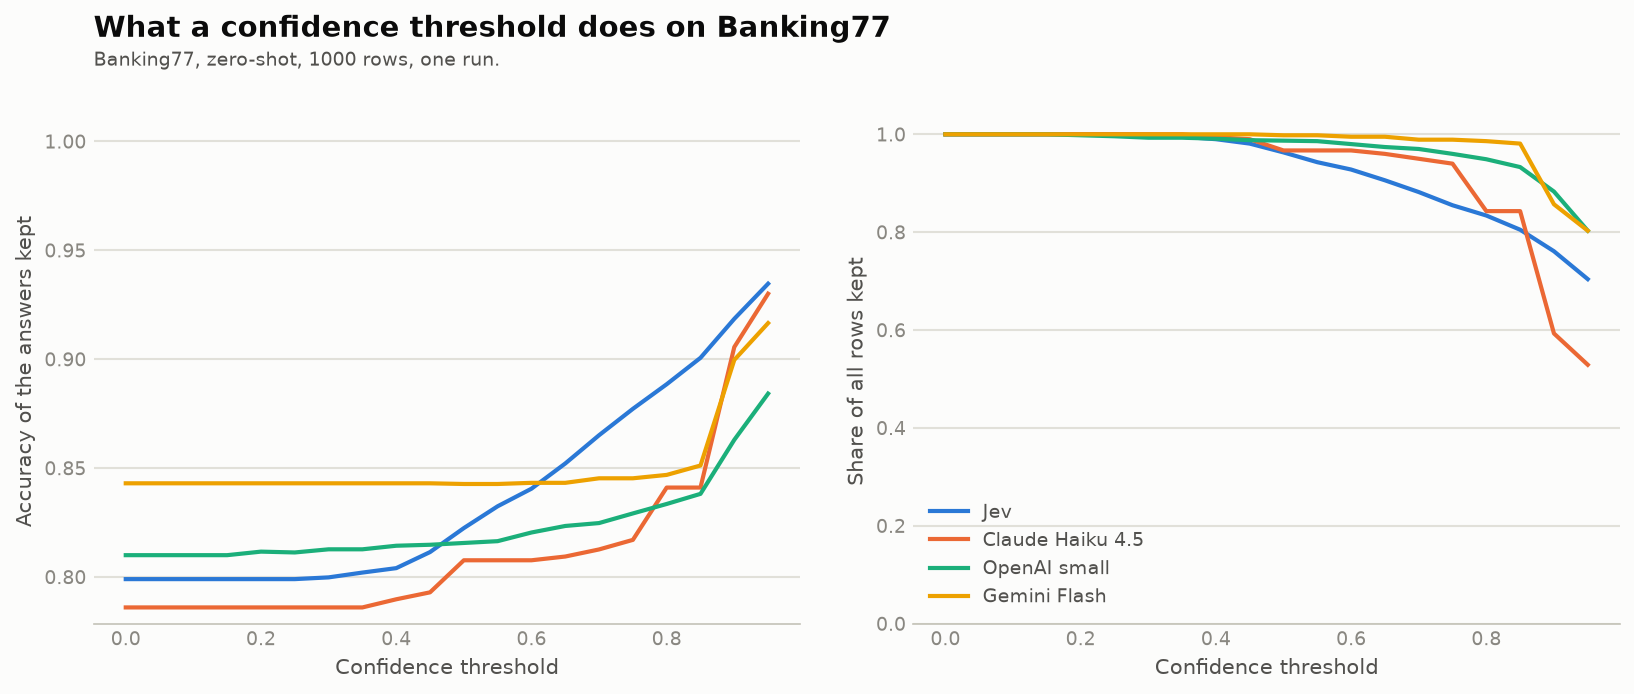

In [12]:
ds = "banking77"
display(show_gated(ds))
fig = gated_figure(ds)

**What the curves show.** Accuracy rises with the threshold for every model, by different amounts.
At a threshold of 0.9, Jev's accuracy is 0.919 with 76% of rows kept, Haiku's is 0.906 with 59%,
OpenAI's is 0.863 with 88% and Gemini's is 0.900 with 86%. At 0.95 the figures are 0.935 (70% kept)
for Jev, 0.930 (53%) for Haiku, 0.884 (80%) for OpenAI and 0.917 (80%) for Gemini. Gemini is the most
accurate with no threshold (0.843), but its confidence separates right from wrong answers little
below 0.9: 99% of its rows have a confidence of at least 0.7, and its accuracy there is 0.845. From
a threshold of 0.7 up, Jev's accuracy is two to four points higher than Gemini's, and the intervals
overlap or only just separate. At 0.95 Gemini still keeps more rows (80% against 70%). OpenAI's
accuracy rises least (0.810 to 0.884). The intervals are for each model separately and are not
paired comparisons.

### AG News

Jev                         Claude Haiku 4.5                         OpenAI small                         Gemini Flash                        
          share kept accuracy [95% interval]       share kept accuracy [95% interval]   share kept accuracy [95% interval]   share kept accuracy [95% interval]
threshold                                                                                                                                                      
0.00           1.000    0.881 [0.859, 0.900]            1.000    0.858 [0.835, 0.878]        1.000    0.859 [0.836, 0.879]        1.000    0.905 [0.885, 0.922]
0.50           0.971    0.890 [0.869, 0.908]            0.984    0.866 [0.843, 0.886]        1.000    0.859 [0.836, 0.879]        1.000    0.905 [0.885, 0.922]
0.70           0.930    0.904 [0.884, 0.922]            0.971    0.868 [0.845, 0.888]        0.989    0.862 [0.840, 0.883]        0.970    0.913 [0.894, 0.930]
0.80           0.904    0.912 [0.891, 0.928]            0.898    0.885 [0.863, 0.905]        0.965    0.878 [0.856, 0.897]        0.928    0.926 [0.907, 0.941]
0.90           0.879    0.917 [0.897, 0.933]            0.763    0.910 [0.887, 0.928]        0.912    0.896 [0.874, 0.914]        0.754    0.958 [0.941, 0.970]
0.95           0.843    0.926 [0.907, 0.942]            0.562    0.929 [0.905, 0.947]        0.854    0.909 [0.887, 0.926]        0.739    0.959 [0.943, 0.971]

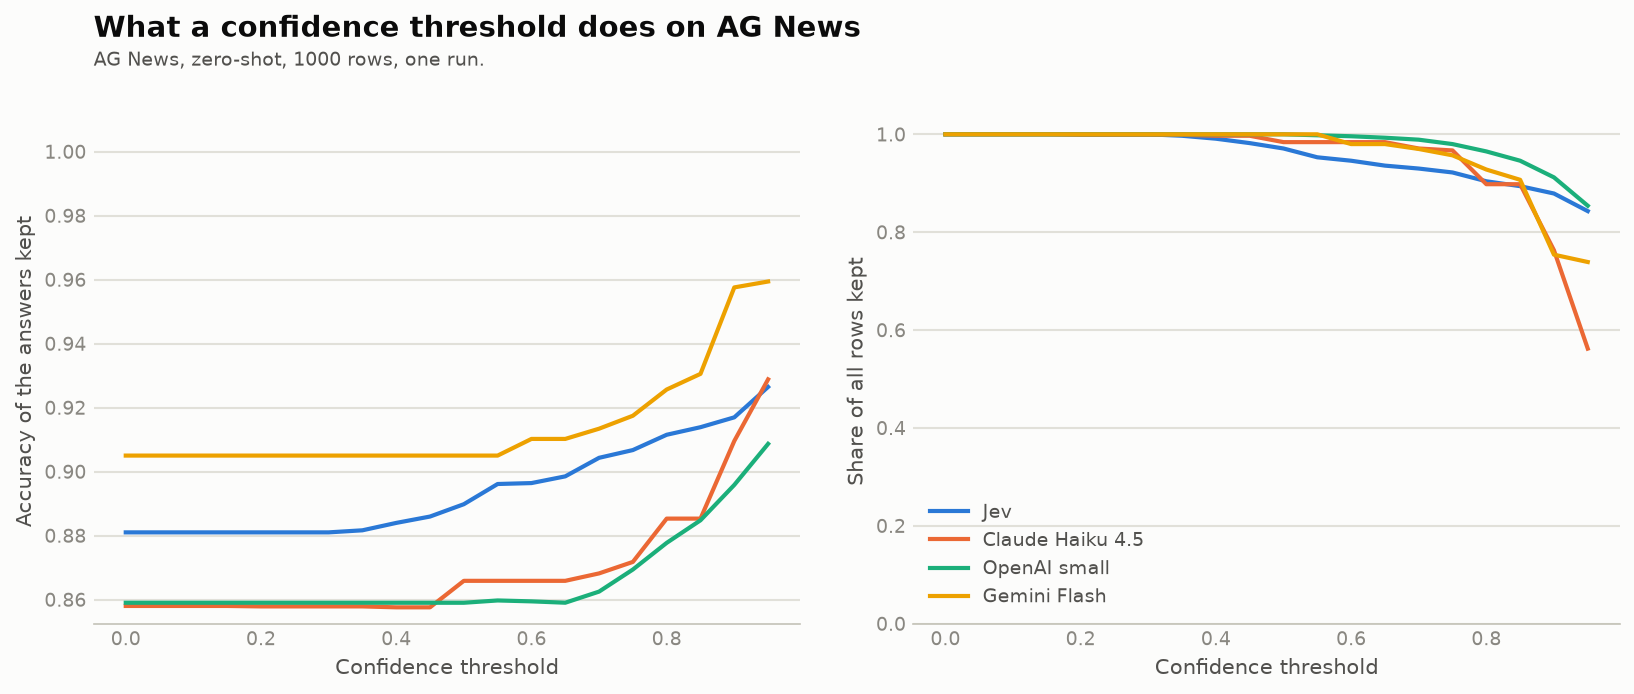

In [13]:
ds = "ag_news"
display(show_gated(ds))
fig = gated_figure(ds)

**What the curves show.** Gemini has the highest accuracy at every threshold: 0.905 with no
threshold, 0.958 at 0.9 (75% of rows kept) and 0.959 at 0.95 (74%). Jev goes from 0.881 to 0.917 at
0.9 (88% kept) and 0.926 at 0.95 (84%). Haiku goes from 0.858 to 0.910 and 0.929, but keeps 76% and
56% of rows at those thresholds, because its confidence takes few values. OpenAI goes to 0.896 and
0.909, keeping 91% and 85%. At 0.95 the accuracies of Jev, Haiku and OpenAI are within 0.02 of each
other and their intervals overlap.

### IMDb

Jev                         Claude Haiku 4.5                         OpenAI small                         Gemini Flash                        
          share kept accuracy [95% interval]       share kept accuracy [95% interval]   share kept accuracy [95% interval]   share kept accuracy [95% interval]
threshold                                                                                                                                                      
0.00           1.000    0.955 [0.940, 0.966]            1.000    0.956 [0.941, 0.967]        1.000    0.961 [0.947, 0.971]        1.000    0.962 [0.948, 0.972]
0.50           0.979    0.966 [0.953, 0.976]            1.000    0.956 [0.941, 0.967]        1.000    0.961 [0.947, 0.971]        1.000    0.962 [0.948, 0.972]
0.70           0.965    0.971 [0.958, 0.980]            1.000    0.956 [0.941, 0.967]        0.990    0.963 [0.950, 0.973]        0.989    0.965 [0.952, 0.975]
0.80           0.959    0.974 [0.962, 0.982]            0.899    0.983 [0.973, 0.990]        0.967    0.970 [0.957, 0.979]        0.962    0.973 [0.960, 0.981]
0.90           0.944    0.977 [0.965, 0.984]            0.808    0.993 [0.984, 0.997]        0.926    0.978 [0.967, 0.986]        0.894    0.991 [0.982, 0.995]
0.95           0.926    0.977 [0.965, 0.985]            0.664    0.995 [0.987, 0.998]        0.872    0.986 [0.976, 0.992]        0.888    0.991 [0.982, 0.995]

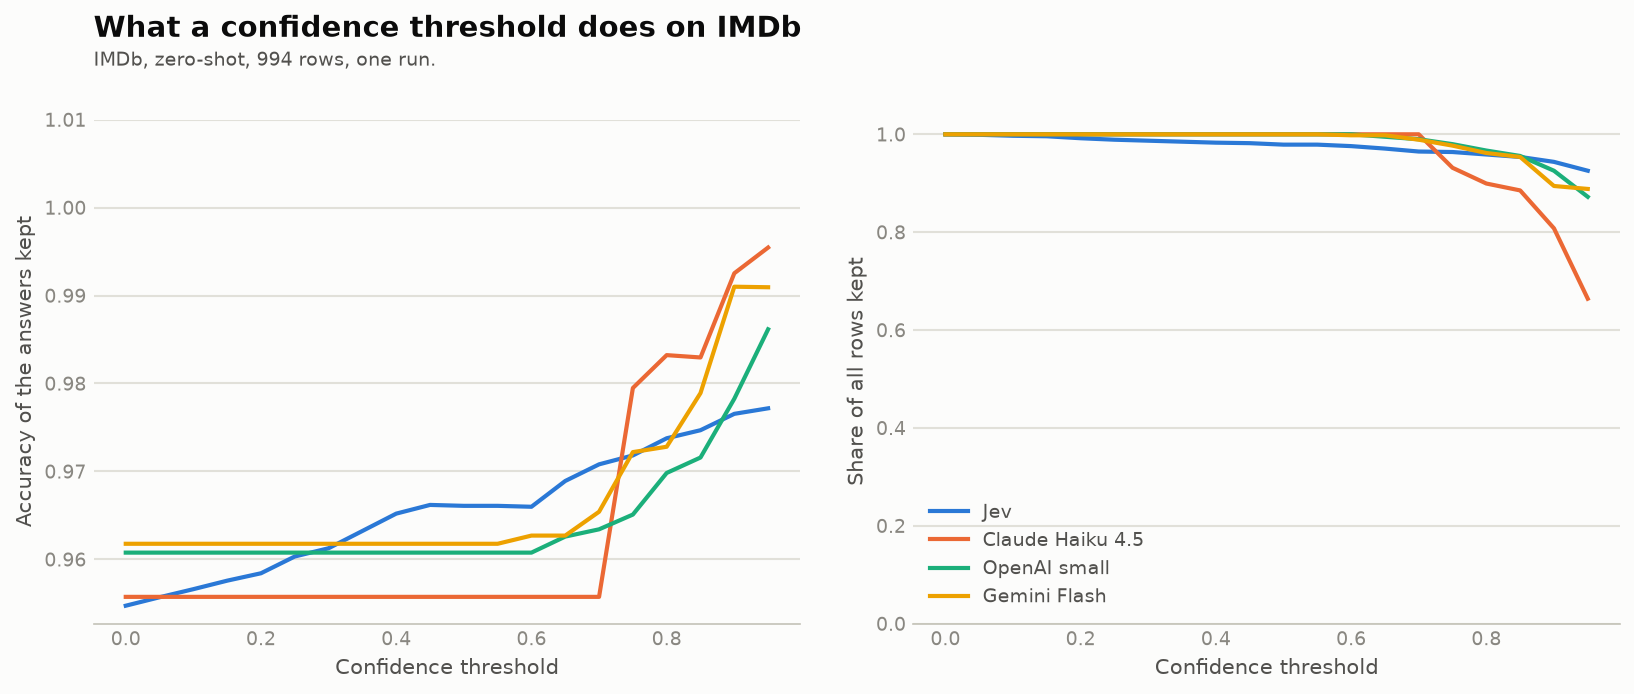

In [14]:
ds = "imdb"
display(show_gated(ds))
fig = gated_figure(ds)

**What the curves show.** Accuracy is already 0.955 to 0.962 with no threshold, so a threshold has
little to add. The models differ in how much it adds and what it costs in rows. At 0.95 Haiku
reaches 0.995 with 66% of rows kept, Gemini 0.991 with 89%, OpenAI 0.986 with 87% and Jev 0.977 with
93%. Jev's accuracy rises least.

## 7. The most confident wrong answers

The reliability diagrams show how often a model is wrong at a given confidence. These tables list
individual rows: the three wrong answers with the highest stated confidence for each model. They
show what kind of mistake gets through a confidence threshold. Some labels overlap, so a wrong
answer may be a defensible reading of the text. That is a judgement to make from the text, not from
the score. Long texts are cut at 110 characters.

In [15]:
def most_confident_wrong(ds, n=3):
    parts = []
    for k in KEYS:
        e = EVAL[(ds, k)]
        wrong = e[~CORRECT[(ds, k)]].assign(confidence=lambda d: d.confidence.astype(float))
        top = wrong.sort_values("confidence", ascending=False).head(n)
        parts.append(
            top.assign(model=NAMES[k], wrong=f"{len(wrong)} of {len(e)}")[
                ["model", "wrong", "confidence", "true_label", "pred", "text"]
            ].reset_index()
        )
    out = pd.concat(parts, ignore_index=True)
    out["text"] = out.text.str.replace(r"\s+", " ", regex=True).str.slice(0, 110)
    return out.set_index(["model", "wrong"])

### Banking77

In [16]:
most_confident_wrong("banking77")

row_id  confidence                 true_label                    pred                                                                                                           text
model            wrong                                                                                                                                                                                            
Jev              201 of 1000      11        1.00               card_arrival  card_delivery_estimate                                                                            How long does a card delivery take?
                 201 of 1000    1006        1.00            top_up_reverted           top_up_failed                                                                             The app wouldn't accept my top up.
                 201 of 1000    1225        1.00  unable_to_verify_identity      verify_my_identity                                                                                What do i need to verify my id?
Claude Haiku 4.5 214 of 1000      11        0.95               card_arrival  card_delivery_estimate                                                                            How long does a card delivery take?
                 214 of 1000     304        0.95     card_delivery_estimate            card_arrival                                                                                     When will the card arrive?
                 214 of 1000     284        0.95     card_delivery_estimate            card_arrival                                                                 I'm just wondering when my card will get here.
OpenAI small     190 of 1000      11        0.99               card_arrival  card_delivery_estimate                                                                            How long does a card delivery take?
                 190 of 1000    2763        0.99            exchange_charge           exchange_rate                                                                             Where do I find the exchange rate?
                 190 of 1000    2190        0.99    beneficiary_not_allowed         failed_transfer                                                                The account transfer I was trying to do failed.
Gemini Flash     157 of 1000      11        0.99               card_arrival  card_delivery_estimate                                                                            How long does a card delivery take?
                 157 of 1000     537        0.99                pin_blocked          card_swallowed  I attempted to use my card while I was intoxicated, and I failed to input my PIN, and the machine kept my ...
                 157 of 1000    2092        0.99     reverted_card_payment?   declined_card_payment  My card is being declined for a purchase. I bought items before and the card worked. Do you know what the ...

### AG News

In [17]:
most_confident_wrong("ag_news")

row_id  confidence true_label      pred                                                                                                           text
model            wrong                                                                                                                                                              
Jev              119 of 1000      56       1.000      World  Business  India's Tata expands regional footprint via NatSteel buyout (AFP) AFP - India's Tata Iron and Steel Compan...
                 119 of 1000     369       1.000      World    Sports  U.S. Softball Team Wins, Closes in on Gold ATHENS, Greece - Right now, the Americans aren't just a Dream T...
                 119 of 1000    1037       1.000   Sci/Tech  Business  SAP software exposes shipper's financial errors The installation of SAP financial software at a major Lond...
Claude Haiku 4.5 142 of 1000     369       0.990      World    Sports  U.S. Softball Team Wins, Closes in on Gold ATHENS, Greece - Right now, the Americans aren't just a Dream T...
                 142 of 1000    1725       0.980   Sci/Tech  Business  Oracle 1Q Earnings Rise 16 Percent (AP) AP - Business software giant Oracle Corp. said Tuesday that first-...
                 142 of 1000    4234       0.980      World    Sports  Cricket: Pakistan edge ahead Pakistan take a slim lead over Sri Lanka by the end of the day two in the fir...
OpenAI small     141 of 1000      56       0.990      World  Business  India's Tata expands regional footprint via NatSteel buyout (AFP) AFP - India's Tata Iron and Steel Compan...
                 141 of 1000     369       0.990      World    Sports  U.S. Softball Team Wins, Closes in on Gold ATHENS, Greece - Right now, the Americans aren't just a Dream T...
                 141 of 1000    6509       0.990      World  Business  Death bell tolls for Russia's Yukos oil giant (AFP) AFP - Russia's Yukos does not begin the week teetering...
Gemini Flash     95 of 1000      369       0.999      World    Sports  U.S. Softball Team Wins, Closes in on Gold ATHENS, Greece - Right now, the Americans aren't just a Dream T...
                 95 of 1000       56       0.990      World  Business  India's Tata expands regional footprint via NatSteel buyout (AFP) AFP - India's Tata Iron and Steel Compan...
                 95 of 1000     1668       0.990   Business     World  EU increases pressure for rights in Myanmar EU foreign ministers agreed Monday to tighten sanctions agains...

### IMDb

In [18]:
most_confident_wrong("imdb")

row_id  confidence true_label      pred                                                                                                           text
model            wrong                                                                                                                                                            
Jev              45 of 994     230        1.00   negative  positive  I suppose I can see why critics give this film two out five stars, it isn't fantastic, but I think it is w...
                 45 of 994   21540        1.00   positive  negative  The new voices scare me! Kuzco doesn't have to pass some frickkin' academy to become emperor again! It's t...
                 45 of 994   20122        1.00   positive  negative  I saw this movie for a first time years ago, when it was still new and I was satisfied. It's a great Holly...
Claude Haiku 4.5 44 of 994   21540        0.98   positive  negative  The new voices scare me! Kuzco doesn't have to pass some frickkin' academy to become emperor again! It's t...
                 44 of 994    6546        0.95   negative  positive  Masterpiece. Carrot Top blows the screen away. Never has one movie captured the essence of the human spiri...
                 44 of 994    9103        0.95   negative  positive  I really enjoyed the film. It was really cheesy at times. (They destroy the villain with hair driers--but ...
OpenAI small     39 of 994   21540        0.99   positive  negative  The new voices scare me! Kuzco doesn't have to pass some frickkin' academy to become emperor again! It's t...
                 39 of 994    9103        0.99   negative  positive  I really enjoyed the film. It was really cheesy at times. (They destroy the villain with hair driers--but ...
                 39 of 994    6546        0.99   negative  positive  Masterpiece. Carrot Top blows the screen away. Never has one movie captured the essence of the human spiri...
Gemini Flash     38 of 994    9103        0.99   negative  positive  I really enjoyed the film. It was really cheesy at times. (They destroy the villain with hair driers--but ...
                 38 of 994   21540        0.99   positive  negative  The new voices scare me! Kuzco doesn't have to pass some frickkin' academy to become emperor again! It's t...
                 38 of 994   10298        0.98   negative  positive  Don't worry when looking at the cover of the DVD, Sandra Bullock only appears at most 5 minutes in total i...

**What the rows show.** The same rows come up for several models, which suggests overlapping or
doubtful labels more than model errors. On Banking77, row 11 ("How long does a card delivery take?",
labelled `card_arrival`) is on all four lists, and the other rows are mostly between neighbouring
intents, such as `card_arrival` and `card_delivery_estimate`, or `exchange_charge` and
`exchange_rate`. On AG News, row 369 (a report of a US softball win in Athens, labelled World and
answered Sports) is on all four lists, and row 56 (an Indian steel takeover, labelled World and
answered Business) is on three. On IMDb, row 21540 is on all four lists and row 9103 on three. Some
texts read as the opposite of their labels: row 6546 ("Masterpiece. Carrot Top blows the screen
away.") is labelled negative, which may be sarcasm or a doubtful label. This is a reading of a few
rows, not a check of the labels.

## 8. Cost and latency

These come from the zero-shot run in notebook 02 (`results/cost_latency.csv`) and are not recomputed. The
check below recomputes the cost from the results files only to confirm that the CSV comes from the
same run. If it does not, run section 8 of notebook 02 again.

Cost per 1,000 rows is worked out from the tokens used. For the LLMs it uses the list prices in
`configs/models.json`, with cached tokens at the provider's cache price. For Jev it is the
gateway's list price (`marketCost`), because the gateway charged nothing on this account.
`latency_*` is per call. `wall_*` is per row from the first attempt to the answer, so it includes
waits. Jev's requests were paced client-side to 27 a minute (`requests_per_minute` in
`configs/models.json`), so its `wall_*` figures mostly show that pacing and say little about the
service. Jev goes through the Vercel AI Gateway and the LLMs are called directly, so latency also
reflects the route. Notebook 02 explains the other columns.

In [19]:
cost = pd.read_csv(RESULTS / "cost_latency.csv")
cost = cost[cost.dataset.isin(DATASETS) & (cost["shot"] == SHOT) & cost.model.isin(KEYS)]
cost = cost.set_index(["dataset", "model"]).reindex(pd.MultiIndex.from_product([DATASETS, KEYS]))
for ds in DATASETS:
    for k in KEYS:
        fresh = bench.cost_latency(RAW[(ds, k)], MODELS[k])["cost_usd_per_1k_rows"]
        assert np.isclose(cost.loc[(ds, k), "cost_usd_per_1k_rows"], fresh, rtol=1e-6), (
            f"cost_latency.csv does not match the {k} {ds} results file. "
            "Run notebook 02 section 8 again."
        )
cost[
    [
        "input_tokens_per_row",
        "output_tokens_per_row",
        "cached_share",
        "cost_usd_per_1k_rows",
        "latency_median_s",
        "latency_p95_s",
        "wall_median_s",
        "retry_rate",
    ]
].round(4)

input_tokens_per_row  output_tokens_per_row  cached_share  cost_usd_per_1k_rows  latency_median_s  latency_p95_s  wall_median_s  retry_rate
banking77 jev                2403.6800               828.2540        0.0000                0.1010            0.3213         0.5085         8.8902       0.047
          haiku              2710.9920                21.4040        0.0000                2.8180            0.8044         1.1182         0.8142       0.105
          openai             1922.4010                21.0000        0.9266                0.3340            0.8141         1.6811         2.2929       0.495
          gemini             1701.5310                51.1780        0.9909                0.3300            1.2120         2.8763         1.2134       0.000
ag_news   jev                 470.2650                47.3800        0.0000                0.0198            0.3039         0.4676         8.8891       0.000
          haiku               417.6560                17.5220        0.0000                0.5053            0.7618         1.1103         0.7618       0.000
          openai              250.3070                18.3660        0.0000                0.2704            0.8535         1.6125         0.8536       0.000
          gemini              207.6850                20.8350        0.0000                0.2339            1.0349         3.4903         1.0350       0.000
imdb      jev                 646.8110                31.0000        0.0000                0.0272            0.3033         0.4816         8.8892       0.000
          haiku               609.5420                17.0000        0.0000                0.6945            0.7575         1.0720         0.7576       0.000
          openai              430.0000                18.5160        0.0000                0.4058            0.8853         1.6589         0.8854       0.000
          gemini              397.0493                22.1258        0.0000                0.3808            1.1467         4.1736         1.1469       0.000

**What the table shows.** At list price Jev is the cheapest per 1,000 rows on every dataset: \$0.10 on
Banking77, \$0.02 on AG News and \$0.03 on IMDb. The cheapest LLM in each case is Gemini, at \$0.33,
\$0.23 and \$0.38. Haiku costs the most (\$2.82, \$0.51 and \$0.69). LLM costs depend on prompt
caching: OpenAI and Gemini served 93% and 99% of their Banking77 input from a cache, and no other
condition shows any caching. The median call takes about 0.30 s for Jev, 0.76 to 0.80 s for Haiku,
0.81 to 0.89 s for OpenAI and 1.03 to 1.21 s for Gemini. Gemini's slowest 5% of calls take up to
4.2 s. Jev's time per row (`wall_median_s`, 8.9 s) is the client-side pacing. OpenAI's on Banking77
(2.3 s, with 49% of rows retried) includes waits after rate-limit responses.

The exact model IDs, as requested and as returned by each API, for the dated record:

In [20]:
used = pd.read_csv(RESULTS / "models_used.csv").set_index("model").loc[KEYS]
used[["model_id_requested", "model_id_returned", "run_date", "params"]]

,model_id_requested,model_id_returned,run_date,params
model,,,,
jev,typesafe-ai/jev,typesafe-ai/jev,2026-09-21,{}
haiku,claude-haiku-4-5-20251001,claude-haiku-4-5-20251001,2026-09-21,"{""extra_body"": {""temperature"": 0}}"
openai,gpt-5.4-mini,gpt-5.4-mini-2026-03-17,2026-09-21,"{""reasoning"": {""effort"": ""none""}}"
gemini,gemini-3.8-flash,gemini-3.8-flash,2026-09-21,"{""temperature"": 0, ""thinking_config"": {""thinking_budget"": 0}}"


In [21]:
buckets = pd.concat(
    [
        t.assign(dataset=ds, model=k, model_id=MODELS[k]["model_id"])
        for (ds, k), t in TABLES.items()
    ],
    ignore_index=True,
)
buckets.to_csv(RESULTS / "calibration_buckets.csv", index=False)
SUMMARY.to_csv(RESULTS / "calibration_summary.csv", index=False)
gated = pd.concat(
    [
        c.assign(dataset=ds, model=k, model_id=MODELS[k]["model_id"])
        for (ds, k), c in CURVES.items()
    ],
    ignore_index=True,
)
gated.to_csv(RESULTS / "calibration_gated.csv", index=False)
print("Written: calibration_buckets.csv, calibration_summary.csv, calibration_gated.csv")

Written: calibration_buckets.csv, calibration_summary.csv, calibration_gated.csv


## 9. Files and caveats

Written to `results/`: `calibration_summary.csv` (accuracy, ECE and Brier score with intervals, and
the differences from Jev, for each dataset), `calibration_buckets.csv` (the reliability tables),
`calibration_gated.csv` (the threshold sweeps), `reliability_<dataset>.png` and
`gated_accuracy_<dataset>.png`. The inputs are the twelve zero-shot results files from notebook 02, the
`sample_<dataset>.csv` files, `cost_latency.csv` and `models_used.csv`.

How far to trust the results:

- **Sample size.** With 1,000 rows per dataset, the overall ECE is reasonably stable, but the buckets at
  low confidence hold few rows for any model that is mostly right. Use the counts and the
  intervals, and do not read one bucket on its own. A larger sample would need its own sample file
  and its own run.
- **Three tasks.** The datasets are clean, well-specified classification tasks, close to what Jev is
  built for. The results do not carry over to other kinds of task.
- **Different mechanisms.** Jev's `confidence` is an output of the model. Each LLM's is a number it
  writes as text. They are different quantities, so a difference in calibration is a difference
  between these ways of producing a confidence, not only between the models. The three LLMs also
  differ in how they were run (see `configs/models.json`), for example in temperature and reasoning
  settings.
- **Model versions.** Jev's response has no version string, only `typesafe-ai/jev`, so the Jev tested
  is that ID as served when the results were produced (20 and 21 September 2026, UTC; the times are
  in section 2). The exact IDs of the LLMs are in the table in
  section 2 and in `results/models_used.csv`.
- **Output format.** The LLMs answered with a label and a confidence in one structured output,
  without reasoning first. Other prompts might give different confidences. This was not tested.
- **Rows.** Each dataset uses the rows that all four models answered. Where a model failed on some
  rows, the other models lose those rows too (section 2).
- **One run.** Each model was run once, at the settings in `configs/models.json`. Run-to-run
  variation is not measured. The intervals cover the choice of test rows only.
- **Public data.** The datasets are public and may be in the LLMs' training data.
- **Buckets.** ECE depends on where the edges fall. A different set of buckets would give a
  different number. The Brier score does not have this problem.